# Growth mixture models

In [1]:
%load_ext autoreload
%autoreload 2

import os

SELECTED_DEVICE = '0'
print(f'Setting CUDA visible devices to [{SELECTED_DEVICE}]')
os.environ['CUDA_VISIBLE_DEVICES'] = f'{SELECTED_DEVICE}'

Setting CUDA visible devices to [0]


In [ ]:
import sys
sys.path.append('/scratch/big/home/maxhin/Documents/Repos/bamojax/')

In [ ]:
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)  # Do we need this here? -> it seems we do for the LML computations (otherwise NaNs get introduced), but not for performance

import jax.random as jrnd
import jax.numpy as jnp
import distrax as dx
import blackjax
from blackjax import normal_random_walk, nuts
from blackjax.diagnostics import effective_sample_size
import pandas as pd
import jax.scipy.special as jsp

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import time


import bamojax
from bamojax.base import Model
from bamojax.sampling import gibbs_sampler, smc_inference_loop, mcmc_sampler, mcmc_inference_loop

print('Python version:       ', sys.version)
print('Jax version:          ', jax.__version__)
print('BlackJax version:     ', blackjax.__version__)
print('Distrax version:      ', dx.__version__)
print('BaMoJax version:      ', bamojax.__version__)
print('Jax default backend:  ', jax.default_backend())
print('Jax devices:          ', jax.devices())

SMALL_SIZE = 14
MEDIUM_SIZE = 16
LARGE_SIZE = 22

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=LARGE_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title

Python version:        3.10.15 (main, Oct  3 2024, 07:27:34) [GCC 11.2.0]
Jax version:           0.4.35
BlackJax version:      1.2.4
Distrax version:       0.1.5
BaMoJax version:       0.0.1
Jax default backend:   gpu
Jax devices:           [CudaDevice(id=0)]


Evaluation and utility functions

In [3]:
from jax.scipy.stats import gaussian_kde

def quantify_multimodality_divergence(samples, varname, vardim, support):
    def KL_MC(p, q, supp, epsilon=1e-8):
        px = p(supp) + epsilon
        qx = q(supp) + epsilon  
        return 1 / len(px) * jnp.sum(px*(jnp.log(px) - jnp.log(qx)))

    #
    m = 1000
    varsupport = jnp.linspace(*support, num=m)
    kl_scores = []
    for k1 in range(K):        
        p = gaussian_kde(samples[varname][:, k1, vardim].flatten())
        for k2 in range(k1+1, K):
            q = gaussian_kde(samples[varname][:, k2, vardim].flatten())
            kl_score = KL_MC(p, q, varsupport)
            kl_scores.append(kl_score)
    return kl_scores

#
def multimodality_kl_score(samples, c):
    variable_settings = dict(beta0 = dict(name='beta',
                                        dim=0,
                                        support=[2.2, 3.2]),
                            beta1 = dict(name='beta',
                                        dim=1,
                                        support=[0.0, 1.5]))

    kl_scores_combined = []
    samples_c = select_chain(samples, chain=c)
    for var_settings in variable_settings.values():
        kl_scores = quantify_multimodality_divergence(samples_c, var_settings['name'], var_settings['dim'], var_settings['support'])
        kl_scores_combined.append(kl_scores)
    return jnp.mean(jnp.asarray(kl_scores_combined))

#
def data_fit(model, samples, num_chains=1):
    """ Computes E_p(theta|D) [p(D | theta)]
    
    """
    loglikelihood_fn = model.loglikelihood_fn()
    if num_chains > 1:
        return jnp.mean(jax.vmap(jax.vmap(loglikelihood_fn))(samples), axis=1)
    else:
        return jnp.mean(jax.vmap(loglikelihood_fn)(samples))

#
def centered_softmax(v):
    return jax.nn.softmax(jnp.insert(v, 0, 0, axis=0))

#
def select_chain(samples, chain):
    return jax.tree_util.tree_map(lambda x: x[chain, ...], samples)

#

Plotting functions

In [4]:
def plot_fit(key, Y, smpls, K, degree, color=None, ax=None, title=None):
    if color is None:
        color = 'tab:orange'

    def plot_predictions(key, ax, beta_samples):
        for i in range(0, num_smpls, 5):
            for k in range(K):
                beta = beta_samples[i, k, :]
                mu = jnp.dot(beta, x)
                ax.plot(x[1, :], mu, color=color, alpha=0.01)

        for i in range(T):            
            jitter = 0.005*jrnd.normal(key, shape=(N, ))
            ax.plot(jitter+x[1, i], Y[:, i], '.', color='k', alpha=0.5)

    #
    def decorate_axis(ax):
        ax.set_xlabel('Semester', fontsize=MEDIUM_SIZE)
        ax.set_xlim([-0.1, 1.1])
        ax.set_ylim([1.0, 4.5])
        ax.set_xticks(jnp.linspace(0, 1, T), jnp.arange(T) + 1, fontsize=SMALL_SIZE)
        ax.tick_params(axis='y', labelsize=SMALL_SIZE)

        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
    
    #

    N, T = Y.shape
    get_polynomial = lambda x, d: x**d
    x = jax.vmap(get_polynomial, in_axes=(None, 0))(jnp.linspace(0, 1, num=T), jnp.arange(degree + 1))

    if jnp.ndim(smpls['beta']) == 4:
        # multiple chains
        num_chains, num_smpls, _, _ = smpls['beta'].shape
    else:    
        num_smpls = smpls['beta'].shape[0]
        num_chains = 1

    if num_chains > 1:
        _, axes = plt.subplots(nrows=1, ncols=num_chains, figsize=(num_chains*6, 3), sharex=True, sharey=True, constrained_layout=True)
        
        for c, ax in enumerate(axes):            
            plot_predictions(key, ax, smpls['beta'][c, ...])
            decorate_axis(ax)
        if title is not None:
            plt.suptitle(title, fontsize=MEDIUM_SIZE)
        axes[0].set_ylabel('GPA', fontsize=MEDIUM_SIZE)
        return axes
    else:
        if ax is None:
            plt.figure(figsize=(8, 4))
            ax = plt.gca()
        if title is not None:
            ax.set_title(title, fontsize=MEDIUM_SIZE)
        plot_predictions(key, ax, smpls['beta'])
        decorate_axis(ax)
        ax.set_ylabel('GPA', fontsize=MEDIUM_SIZE)
        return ax

#
def plot_posterior(smpls, K, degree, title=None):
    if title == None:
        title = ''
    nbins=40

    _, axes = plt.subplots(nrows=K, ncols=degree+1, constrained_layout=True, figsize=(8, K*2), sharex='col', sharey='col')
    for k in range(K):
        for j in range(degree+1):        
            axes[k, j].hist(smpls['beta'][:, k, j].flatten(), bins=nbins, density=True)
            axes[k, j].set_xlabel(r'$\eta_{{{:s}}}$'.format(f'{k},{j}'), fontsize=SMALL_SIZE)
        axes[k,0].set_ylabel(f'Component {k+1}', fontsize=SMALL_SIZE)
    plt.suptitle(f'Coefficients for different polynomial orders ({title})', fontsize=MEDIUM_SIZE)
    plt.show()

    _, axes = plt.subplots(nrows=1, ncols=K, constrained_layout=True, figsize=(8, 2), sharex=True, sharey=True)
    for k, ax in enumerate(axes):
        ax.hist(smpls['sd'][:, k], bins=nbins, density=True)
        ax.set_xlabel(fr'$\sigma_{k+1}$', fontsize=SMALL_SIZE)
    plt.suptitle(f'Observation noise per component ({title})', fontsize=MEDIUM_SIZE)
    plt.show()

    w_raw = smpls['w_raw']
    w = jnp.squeeze(jax.vmap(centered_softmax, in_axes=0)(w_raw))

    _, axes = plt.subplots(nrows=1, ncols=K, constrained_layout=True, figsize=(8, 2), sharex=True, sharey=True)
    for k, ax in enumerate(axes):
        ax.hist(w[:, k], bins=nbins, density=True)
        ax.set_xlabel(fr'$w_{k+1}$', fontsize=SMALL_SIZE)
    plt.suptitle(f'Component weight ({title})', fontsize=MEDIUM_SIZE)
    plt.show()

#

Load data

In [5]:
url = 'https://jasp-stats.org/wp-content/uploads/2022/02/gpa.csv'
df = pd.read_csv(url)

Y = df[['gpa1', 'gpa2', 'gpa3', 'gpa4', 'gpa5', 'gpa6']].to_numpy()
N, T = Y.shape

degree = 1

get_polynomial = lambda x, d: x**d
X = jax.vmap(get_polynomial, in_axes=(None, 0))(jnp.linspace(0, 1, num=T), jnp.arange(degree + 1))

Construct Growth Mixture Model using BaMoJax

In [6]:
def grmm_link_fn(w_raw, beta, sd, x):
    mu = jnp.dot(beta, x)
    probs = centered_softmax(w_raw).T
    sd = jnp.expand_dims(sd, axis=1) * jnp.ones((1, T))
    mixture_dist = dx.Categorical(probs=probs)
    component_dist = dx.MultivariateNormalDiag(loc=mu, scale_diag=sd)
    return dict(mixture_distribution=mixture_dist,
                components_distribution=component_dist)

#
def make_grmm(X, Y, degree, K):
    GrMM = Model('Growth mixture model')
    w_node = GrMM.add_node('w_raw', distribution=dx.Normal(loc=0.0, scale=1.0), shape=(K-1, ))
    beta_node = GrMM.add_node('beta', distribution=dx.Normal(loc=0.0, scale=2.0), shape=(K, degree + 1))
    sd_node = GrMM.add_node('sd', distribution=dx.Transformed(dx.Normal(loc=0.0, scale=1.0), tfb.Exp()), shape=(K, ))
    x_node = GrMM.add_node('X', observations=X)
    y_node = GrMM.add_node('Y', 
                        observations=Y, 
                        distribution=dx.MixtureSameFamily,
                        link_fn=grmm_link_fn,
                        parents=dict(w_raw=w_node, beta=beta_node, sd=sd_node, x=x_node))
    return GrMM

#

K = 4
GrMM = make_grmm(X, Y, degree=degree, K=K)
GrMM.print_gibbs()

Gibbs structure:
w_raw               : p(Y | sd, beta, X, w_raw) p(w_raw)
beta                : p(Y | sd, beta, X, w_raw) p(beta)
sd                  : p(Y | sd, beta, X, w_raw) p(sd)


Set up MCMC kernels

In [15]:
# Metropolis-Hastings

rmh_params = dict(sigma=0.01*jnp.eye(GrMM.get_model_size()))
rmh = mcmc_sampler(GrMM, mcmc_kernel=normal_random_walk, mcmc_parameters=rmh_params)

# Gibbs

step_fns = dict(beta=normal_random_walk, 
                w_raw=normal_random_walk,
                sd=normal_random_walk)
step_fn_params = dict(beta=dict(sigma=0.1*jnp.eye(K*(degree+1))), 
                      w_raw=dict(sigma=0.1*jnp.eye(K-1)), 
                      sd=dict(sigma=0.1*jnp.eye(K)))

gibbs = gibbs_sampler(GrMM, step_fns=step_fns, step_fn_params=step_fn_params)

# NUTS HMC; warmup takes about 30 seconds

start_warmup = time.time()
key = jrnd.PRNGKey(42)
key, k_init, k_warmup = jrnd.split(key, 3)
num_warmup = 500
logdensity_fn = lambda state: GrMM.loglikelihood_fn()(state) + GrMM.logprior_fn()(state)
warmup = blackjax.window_adaptation(nuts, logdensity_fn)
(_, warm_parameters), _ = warmup.run(k_warmup, GrMM.sample_prior(k_init), num_steps=num_warmup)  
stop_warmup = time.time()
warmup_time = stop_warmup - start_warmup
nuts_sampler = mcmc_sampler(GrMM, mcmc_kernel=nuts, mcmc_parameters=warm_parameters)

Run MCMC until convergence for different MCMC kernels:

In [ ]:
%%time
key = jrnd.PRNGKey(12345)
num_chains = 4

# num_samples was increased until the fit converged
kernels = {}
kernels['MH'] = dict(kernel=rmh, num_samples=[2_000_000]) 
kernels['Gibbs'] = dict(kernel=gibbs, num_samples=[1_250_000])  
kernels['NUTS'] = dict(kernel=nuts_sampler, num_samples=[20_000])  

mcmc_results = {}

for name, settings in kernels.items():
    mcmc_results[name] = []
    for num_samples in settings['num_samples']:
        key, subkey = jrnd.split(key)
        start = time.time()
        num_burn = num_samples
        num_thin = int(num_samples / num_particles)  # ensure MCMC and SMC have the same number of samples of the posterior
        samples = mcmc_inference_loop(key=subkey, 
                                      model=GrMM,
                                      kernel=settings['kernel'], 
                                      num_samples=num_samples, 
                                      num_burn=num_burn, 
                                      num_thin=num_thin, 
                                      num_chains=num_chains,
                                      store_diagnostics=False)
        stop = time.time()
        elapsed = stop - start
        result_dict = {}
        result_dict['samples'] = samples
        result_dict['time_elapsed'] = elapsed
        mcmc_results[name].append(result_dict)
        fit = data_fit(GrMM, samples.position, num_chains)
        if num_chains > 1:
            print(f'{name}: Log-likelihood for {num_samples} steps (done in {elapsed:0.2f} seconds): {jnp.mean(fit):0.3f} (SD: {jnp.std(fit):0.3f})')
        else:
            print(f'{name}: Log-likelihood for {num_samples} steps (done in {elapsed:0.2f} seconds): {fit:0.3f}')

mcmc_results_file = '/home/maxhin/Documents/Code/SMC tutorial/GMM/review1/GrMM/mcmc_results.npy'

jnp.save(mcmc_results_file, mcmc_results)

Gibbs: Log-likelihood for 1250000 steps (done in 550.91 seconds): -157.976 (SD: 2.924)
CPU times: user 6min 34s, sys: 2min 38s, total: 9min 12s
Wall time: 9min 11s


In [ ]:
mcmc_results_file = '/home/maxhin/Documents/Code/SMC tutorial/GMM/review1/GrMM/mcmc_results.npy'
mcmc_results = jnp.load(mcmc_results_file, allow_pickle=True).item()

Similarly run SMC until convergence for different mutation kernels and number of mutation steps

In [ ]:
%%time
key = jrnd.PRNGKey(42) 
num_chains = 4
num_particles = 2000

# At these final values the log-likelihood is approximately -156, which seems near the optimum when looking at the NUTS results
kernels = {}
kernels['MH-in-SMC'] = dict(kernel=rmh, num_steps=[800])
kernels['Gibbs-in-SMC'] = dict(kernel=gibbs, num_steps=[50])
kernels['NUTS-in-SMC'] = dict(kernel=nuts_sampler, num_steps=[1])

smc_results = {}

for name, settings in kernels.items():
    smc_results[name] = []
    for num_mcmc_steps in settings['num_steps']:
        key, subkey = jrnd.split(key)
        start = time.time()
        final_state, lml, num_adapt = smc_inference_loop(subkey, 
                                                         model=GrMM, 
                                                         kernel=settings['kernel'], 
                                                         num_particles=num_particles, 
                                                         num_mcmc_steps=num_mcmc_steps, 
                                                         num_chains=num_chains, 
                                                         store_diagnostics=False)
        stop = time.time()
        elapsed = stop - start
        result_dict = {}
        result_dict['final_state'] = final_state
        result_dict['lml'] = lml
        result_dict['num_adapt'] = num_adapt
        result_dict['time_elapsed'] = elapsed
        smc_results[name].append(result_dict)
        fit = data_fit(GrMM, final_state.particles, num_chains)
        if num_chains > 1:
            print(f'{name}: Log-likelihood for {num_mcmc_steps} mutations (done in {elapsed:0.2f} seconds and {jnp.mean(num_adapt)} cycles): {jnp.mean(fit):0.3f} (SD: {jnp.std(fit):0.3f})')
        else:
            print(f'{name}: Log-likelihood for {num_mcmc_steps} mutations (done in {elapsed:0.2f} seconds and {num_adapt} cycles): {fit:0.3f}')


smc_results_file = '/home/maxhin/Documents/Code/SMC tutorial/GMM/review1/GrMM/smc_results.npy'
jnp.save(smc_results_file, smc_results)

MH-in-SMC: Log-likelihood for 800 mutations (done in 173.04 seconds and 38.5 cycles): -157.202 (SD: 0.286)
Gibbs-in-SMC: Log-likelihood for 50 mutations (done in 40.22 seconds and 38.75 cycles): -157.305 (SD: 0.614)
NUTS-in-SMC: Log-likelihood for 1 mutations (done in 277.06 seconds and 39.25 cycles): -156.835 (SD: 0.395)
CPU times: user 7min 19s, sys: 1min 14s, total: 8min 34s
Wall time: 8min 10s


In [11]:
smc_results_file = '/home/maxhin/Documents/Code/SMC tutorial/GMM/review1/GrMM/smc_results.npy'

smc_results = jnp.load(smc_results_file, allow_pickle=True).item()

Visualize posterior fits to verify model has been trained succesfully:

Construct Table 1.

In [ ]:
num_chains = 4
print(f'     Sampler &       PELL         &       KL       &  ESS &     Time')


def print_results(name, results):
    scores = []
    if 'samples' in results:
        states = results['samples'].position
    elif 'final_state' in results:
        states = results['final_state'].particles
    fit = data_fit(GrMM, states, num_chains)
    for c in range(num_chains):
        scores.append(multimodality_kl_score(states, c))
    scores = jnp.asarray(scores)
    timing = results['time_elapsed']
    if name in ['nuts', 'NUTS-in-SMC']:
        timing += warmup_time  # this also takes time!
    ess = effective_sample_size(states['beta']).flatten().mean()
    print(f'{name:>12s} & {jnp.mean(fit):0.2f} \pm {jnp.std(fit):0.2f} & {jnp.mean(scores):0.2f} \pm {jnp.std(scores):0.2f} & {ess:0.2f} & {timing:0.2f}')


for name, value in mcmc_results.items():
    print_results(name, value[-1])

for name, value in smc_results.items():
    print_results(name, value[-1])


     Sampler &       LL         &       KL       &  ESS &     Time
          MH & -158.45 \pm 4.00 & 12.22 \pm 1.55 & 4.94 & 456.53
       Gibbs & -157.98 \pm 2.92 & 11.04 \pm 2.18 & 4.16 & 550.91
        NUTS & -156.45 \pm 0.27 & 14.73 \pm 0.16 & 2.15 & 242.05
   MH-in-SMC & -157.20 \pm 0.29 & 2.02 \pm 1.18 & 19.66 & 173.04
Gibbs-in-SMC & -157.30 \pm 0.61 & 0.64 \pm 0.13 & 17.77 & 40.22
 NUTS-in-SMC & -156.84 \pm 0.40 & 0.32 \pm 0.16 & 69.75 & 303.27


Make master figure

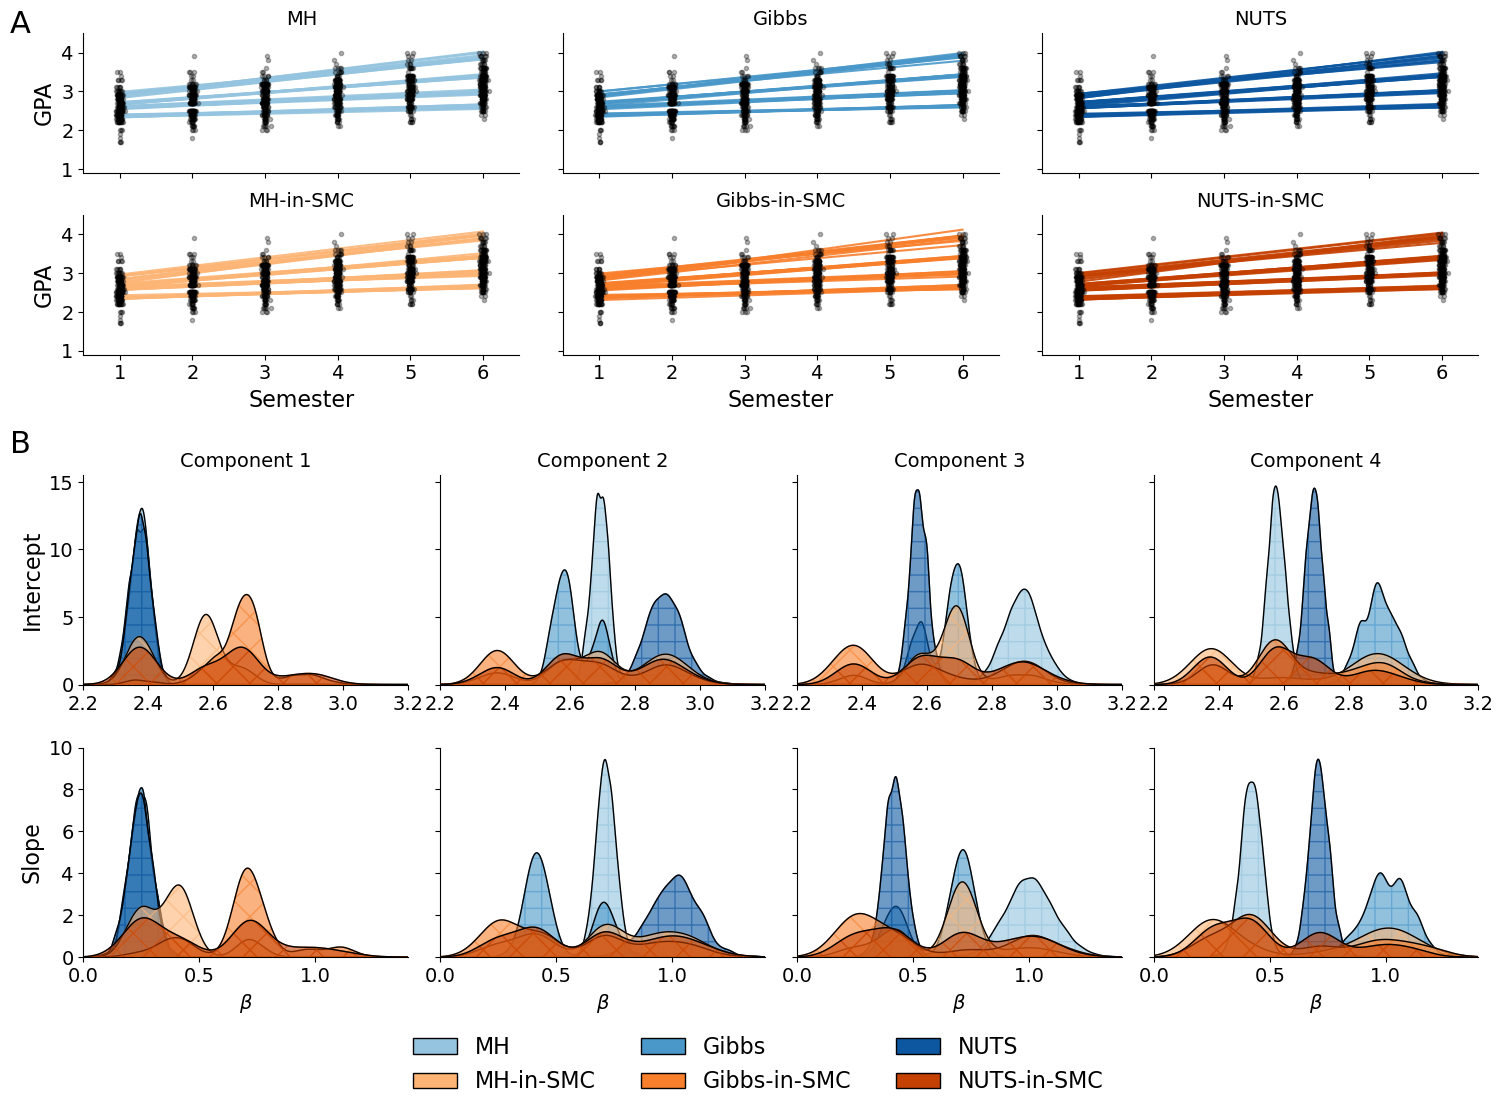

In [96]:
import numpy as np
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

def plot_fit_method(key, Y, results_dict, chain, K, colors, axes):

    def plot_predictions(key, ax, beta_samples, color):
        for i in range(0, num_particles, 200):
            for k in range(K):
                beta = beta_samples[i, k, :]
                mu = jnp.dot(beta, X)
                ax.plot(X[1, :], mu, color=color, alpha=0.9)

        for i in range(T):            
            jitter = 0.005*jrnd.normal(key, shape=(N, ))
            ax.plot(jitter + X[1, i], Y[:, i], '.', color='k', alpha=0.3)

    #
    def decorate_axis(ax):
        ax.set_xlabel('Semester', fontsize=MEDIUM_SIZE)
        ax.set_xlim([-0.1, 1.1])
        ax.set_ylim([1.0, 4.5])
        ax.set_xticks(jnp.linspace(0, 1, T), jnp.arange(T) + 1, fontsize=SMALL_SIZE)
        ax.tick_params(axis='y', labelsize=SMALL_SIZE)
    
    #
    N, T = Y.shape
    for i, (name, results) in enumerate(results_dict.items()):
        if 'samples' in results[-1]:
            plot_predictions(key, axes[i], results[-1]['samples'].position['beta'][chain, ...], color=colors[i])
        else:
            plot_predictions(key, axes[i], results[-1]['final_state'].particles['beta'][chain, ...], color=colors[i])
            decorate_axis(axes[i])
        axes[i].tick_params(axis='y', labelsize=SMALL_SIZE)
        axes[i].set_title(name, fontsize=SMALL_SIZE)
        for spine in ['top', 'right']:
            axes[i].spines[spine].set_visible(False)


    axes[0].set_ylabel('GPA', fontsize=MEDIUM_SIZE)

#

M = len(mcmc_results.keys())

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1.5], hspace=0.3, wspace=0.0)

gs_inference = gs[0].subgridspec(2, M)
gs_coef = gs[1].subgridspec(2, K)

axes_inference = gs_inference.subplots(sharex=True, sharey=True)
axes_coef = gs_coef.subplots(sharex='row', sharey='row')

chain = 2

colors1 = plt.get_cmap('Blues')([0.4, 0.6, 0.85])
colors2 = plt.get_cmap('Oranges')([0.35, 0.55, 0.8])
colors = np.vstack((colors1, colors2))

plot_fit_method(key, Y, mcmc_results, chain=chain, K=K, colors=colors1, axes=axes_inference[0, :])
plot_fit_method(key, Y, smc_results, chain=chain, K=K, colors=colors2, axes=axes_inference[1, :])

for ax in axes_inference.flatten():
    ax.set_ylim([0.9, 4.5])
    ax.set_yticks(jnp.arange(1, 5))
    ax.set_yticklabels(jnp.arange(1, 5))


param_ranges = {0:jnp.linspace(2.2, 3.2, num=1000), 
                1: jnp.linspace(0.0, 1.4, num=1000)}

ylims = [15.5, 10]

output = [mcmc_results['MH'][-1]['samples'].position, mcmc_results['Gibbs'][-1]['samples'].position, mcmc_results['NUTS'][-1]['samples'].position,
          smc_results['MH-in-SMC'][-1]['final_state'].particles, smc_results['Gibbs-in-SMC'][-1]['final_state'].particles, smc_results['NUTS-in-SMC'][-1]['final_state'].particles]

methodlabels = ['MH', 'Gibbs', 'NUTS', 'MH-in-SMC', 'Gibbs-in-SMC', 'NUTS-in-SMC']
hatches = ['+', '+', '+', 'x', 'x', 'x']

for d in [0, 1]:
    param_range = param_ranges[d]      
    for k in range(K):
        ax = axes_coef[d, k]    
        for m in range(len(methodlabels)):  
            samples = output[m]
            pdf = gaussian_kde(samples['beta'][chain, :, k, d].flatten())
            y = pdf(param_range)
            ax.plot(param_range, y, color='k', lw=1, zorder=m+0.5)
            ax.fill_between(param_range, y, jnp.zeros_like(y), color=colors[m], alpha=0.6, zorder=m, label=methodlabels[m], hatch=hatches[m])
            ax.tick_params(axis='both', labelsize=SMALL_SIZE)
            ax.set_xlim([param_range[0], param_range[-1]])
            ax.set_ylim(bottom=0, top=ylims[d])
            for spine in ['top', 'right']:
                ax.spines[spine].set_visible(False)       

for k in range(K):
    axes_coef[0, k].set_title(f'Component {k+1}', fontsize=SMALL_SIZE)
    axes_coef[1, k].set_xlabel(r'$\beta$', fontsize=SMALL_SIZE)
        
axes_coef[0, 0].set_ylabel('Intercept', fontsize=MEDIUM_SIZE)
axes_coef[1, 0].set_ylabel('Slope', fontsize=MEDIUM_SIZE);

plt.subplots_adjust(wspace=0.1, hspace=0.3)

plt.figtext(0.09, 0.88, 'A', size=LARGE_SIZE, ha='center', transform=plt.gcf().transFigure)
plt.figtext(0.09, 0.53, 'B', size=LARGE_SIZE, ha='center', transform=plt.gcf().transFigure)

handles, labels = axes_coef[1, 0].get_legend_handles_labels()
handles = [Patch(facecolor=color, edgecolor='black', label=label) for color, label in zip(colors, labels)]
order = [0, 3, 1, 4, 2, 5]
fig.legend([handles[ix] for ix in order], [labels[ix] for ix in order], loc='lower center', ncols=M, frameon=False, 
           bbox_to_anchor=(0, -0.02, 1, 1), bbox_transform=plt.gcf().transFigure, fontsize=MEDIUM_SIZE);

plt.savefig(f'/home/maxhin/Documents/Code/SMC tutorial/Review1 results/grmm_combined_figure.pdf', 
            bbox_inches='tight', pad_inches=0.0)


Clearly, the SMC-based methods capture the multimodality much better. Within these methods, Gibbs and NUTS seem comparable in performance, but Gibbs is way faster and therefore preferred. The additional computation required for NUTS is not needed when incorporating these mutations into the SMC routine.